C:\Users\varun\AppData\Local\Temp\ipykernel_37248\3626171135.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(keyword_counts.keys()), y=list(keyword_counts.values()), palette='viridis')


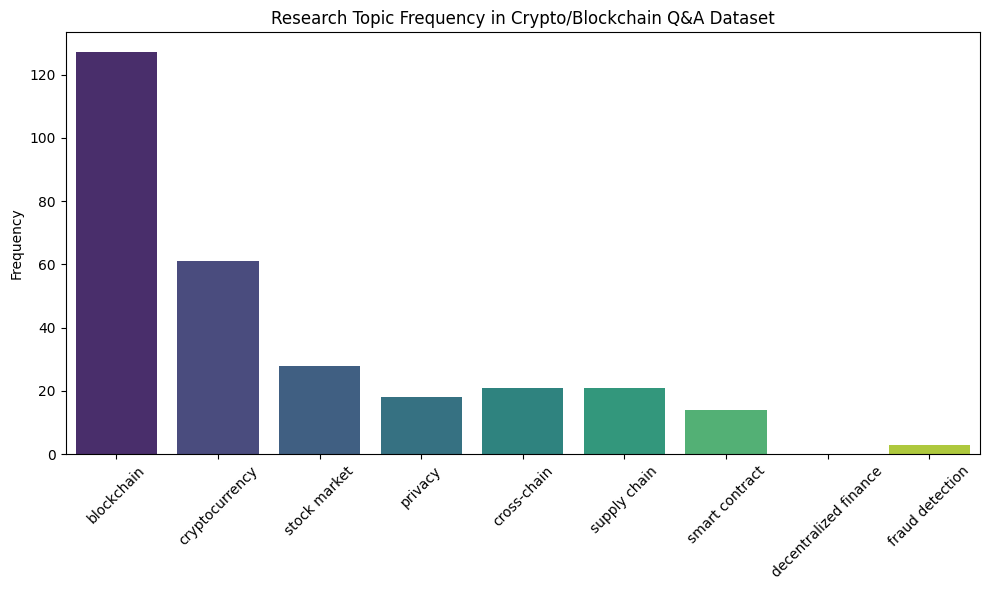

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
train_df = pd.read_csv('../Dataset/LLMcrypto/train.csv')

# Define keywords/topics to count in questions
keywords = ['blockchain', 'cryptocurrency', 'stock market', 'privacy', 'cross-chain', 'supply chain', 'smart contract', 'decentralized finance', 'fraud detection']

# Count occurrences of each keyword in the 'question' column
keyword_counts = {}
for word in keywords:
    count = train_df['question'].str.contains(word, case=False, na=False).sum()
    keyword_counts[word] = count

# Plot the bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=list(keyword_counts.keys()), y=list(keyword_counts.values()), palette='viridis')
plt.title('Research Topic Frequency in Crypto/Blockchain Q&A Dataset')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
train_df = pd.read_csv('../Dataset/LLMcrypto/train.csv')


In [22]:
# 1. First 5 rows overview
print(train_df.head())


   Unnamed: 0                                           question  \
0           0  What significant challenges does the rapid exp...   
1           1  How does the proposed framework address the in...   
2           2  What are the primary benefits of using blockch...   
3           3  Why are traditional blockchain-based solutions...   
4           4  How does the proposed framework ensure data pr...   

                                              answer  \
0  Balancing scalability and security, computatio...   
1  By employing edge aggregating servers and Ethe...   
2  Data integrity, device authentication, and pro...   
3  Due to scalability, cost issues, and computati...   
4  Through the use of Zero-Knowledge Proofs (ZKPs...   

                                                text  
0  ###Human:\nAnswer this question in the context...  
1  ###Human:\nAnswer this question in the context...  
2  ###Human:\nAnswer this question in the context...  
3  ###Human:\nAnswer this question

In [23]:
# 2. Dataset dimensions
print("Dataset shape:", train_df.shape)


Dataset shape: (804, 4)


In [24]:
# 3. Summary statistics
print(train_df.describe(include='all'))


        Unnamed: 0                              question  \
count   804.000000                                   804   
unique         NaN                                   759   
top            NaN  What is the main focus of the study?   
freq           NaN                                     3   
mean    401.500000                                   NaN   
std     232.239101                                   NaN   
min       0.000000                                   NaN   
25%     200.750000                                   NaN   
50%     401.500000                                   NaN   
75%     602.250000                                   NaN   
max     803.000000                                   NaN   

                                                   answer  \
count                                                 804   
unique                                                767   
top     Encryption, role-based access control, and sma...   
freq                               

In [25]:
# 4. Missing values per column
print(train_df.isnull().sum())


Unnamed: 0    0
question      0
answer        0
text          0
dtype: int64


In [26]:
# 5. Unique counts in question and answer columns
print("Unique questions:", train_df['question'].nunique())
print("Unique answers:", train_df['answer'].nunique())


Unique questions: 759
Unique answers: 767


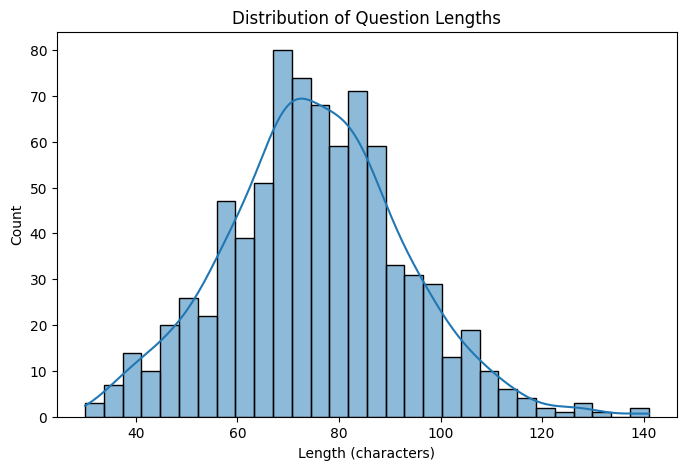

In [27]:
# 6. Distribution of question lengths
train_df['question_length'] = train_df['question'].str.len()
plt.figure(figsize=(8,5))
sns.histplot(train_df['question_length'], bins=30, kde=True)
plt.title('Distribution of Question Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.show()


# Distribution of Question Lengths:
This chart shows the number of characters in each question. Questions mostly vary in length, with many falling between short to medium lengths. Understanding question length helps in preprocessing for AI models, such as setting token limits or padding sizes.

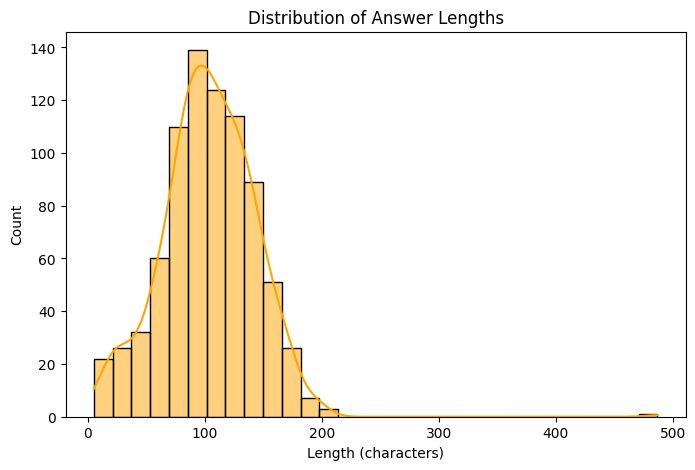

In [28]:
# 7. Distribution of answer lengths
train_df['answer_length'] = train_df['answer'].str.len()
plt.figure(figsize=(8,5))
sns.histplot(train_df['answer_length'], bins=30, kde=True, color='orange')
plt.title('Distribution of Answer Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.show()


# Distribution of Answer Lengths
Answers vary widely in length, with a concentration in medium-length responses. This reflects that some questions require detailed explanations while others are concise. This insight is useful for designing your model’s output handling.

C:\Users\varun\AppData\Local\Temp\ipykernel_37248\1421665725.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(keyword_counts.keys()), y=list(keyword_counts.values()), palette='viridis')


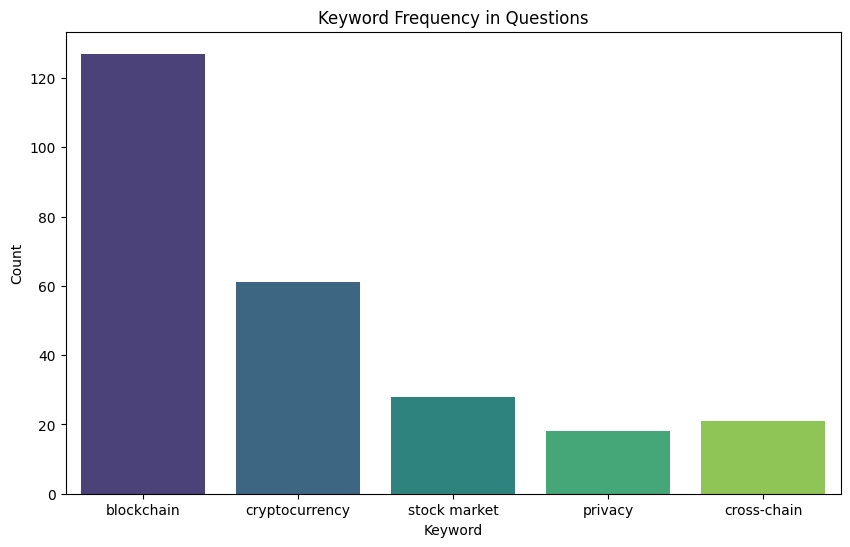

In [29]:
# 8. Keyword counts in questions
keywords = ['blockchain', 'cryptocurrency', 'stock market', 'privacy', 'cross-chain']
keyword_counts = {}
for kw in keywords:
    keyword_counts[kw] = train_df['question'].str.contains(kw, case=False, na=False).sum()

plt.figure(figsize=(10,6))
sns.barplot(x=list(keyword_counts.keys()), y=list(keyword_counts.values()), palette='viridis')
plt.title('Keyword Frequency in Questions')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.show()


# Keyword Frequency in Questions
This bar chart highlights the most common key topics mentioned in questions. “Blockchain” and “cryptocurrency” are the most frequently discussed, showing that these are core themes in your dataset, aligning with your research focus.

C:\Users\varun\AppData\Local\Temp\ipykernel_37248\190323073.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_freq.index, y=word_freq.values, palette='magma')


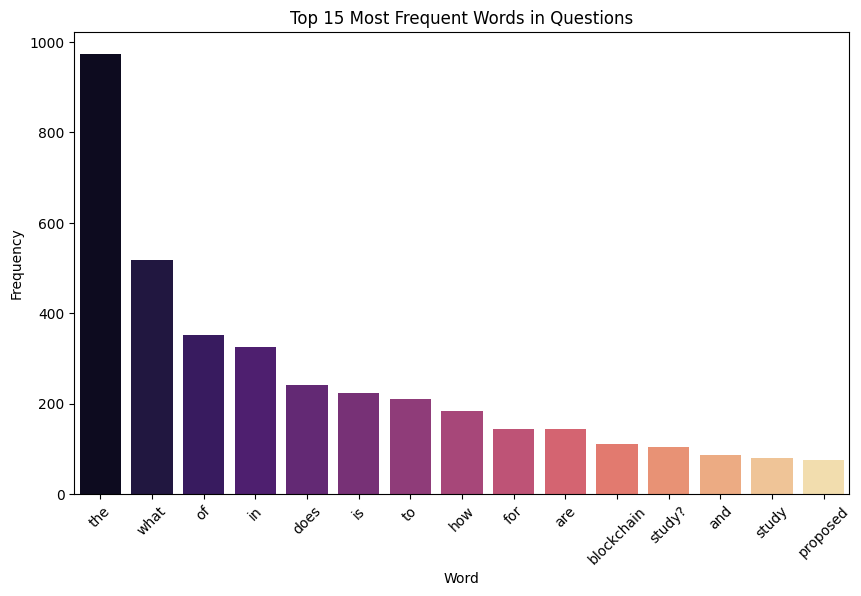

In [30]:
# 9. Most common words in questions (top 15)
questions_text = ' '.join(train_df['question'].dropna()).lower()
words = questions_text.split()
word_freq = pd.Series(words).value_counts()[:15]

plt.figure(figsize=(10,6))
sns.barplot(x=word_freq.index, y=word_freq.values, palette='magma')
plt.xticks(rotation=45)
plt.title('Top 15 Most Frequent Words in Questions')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.show()


# Top 15 Most Frequent Words in Questions
The most common words include “the,” “what,” “of,” and “in,” which are typical common words. Beyond these, words like “study” and “does” show the dataset’s focus on questioning specific topics, indicating useful target vocabulary for language models.



C:\Users\varun\AppData\Local\Temp\ipykernel_37248\810769259.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(start_word_counts.keys()), y=list(start_word_counts.values()), palette='coolwarm')


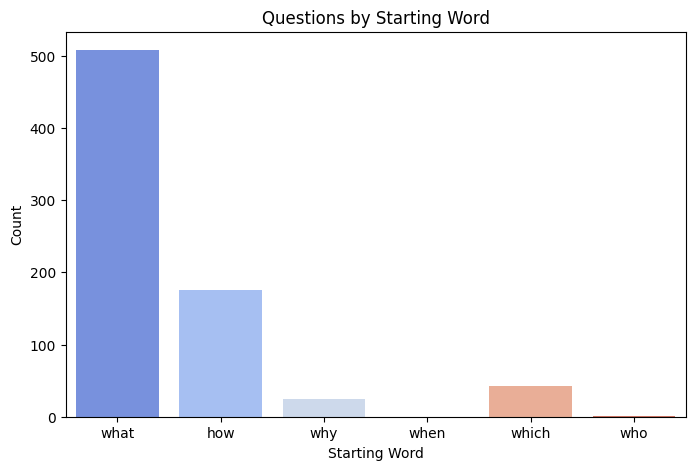

In [31]:
# 10. Count questions by starting word (common interrogatives)
start_words = ['what', 'how', 'why', 'when', 'which', 'who']
start_word_counts = {}
for word in start_words:
    start_word_counts[word] = train_df['question'].str.lower().str.startswith(word).sum()

plt.figure(figsize=(8,5))
sns.barplot(x=list(start_word_counts.keys()), y=list(start_word_counts.values()), palette='coolwarm')
plt.title('Questions by Starting Word')
plt.xlabel('Starting Word')
plt.ylabel('Count')
plt.show()


# Questions by Starting Word
Most questions start with “what” and “how,” reflecting an inquisitive nature aiming to explore explanations and processes. This understanding helps when tailoring NLP models to generate or understand such question types.



C:\Users\varun\AppData\Local\Temp\ipykernel_37248\3542296662.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='first_word', y='answer_length', data=subset, palette='Set2')


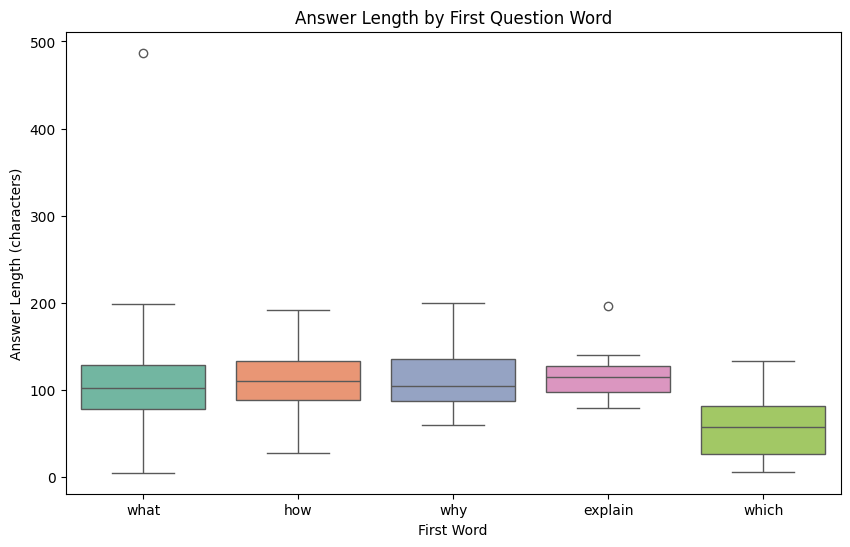

In [32]:
# 11. Boxplot: answer length by first word of question (top 5 first words)
train_df['first_word'] = train_df['question'].str.split().str[0].str.lower()
top_first_words = train_df['first_word'].value_counts().index[:5]
subset = train_df[train_df['first_word'].isin(top_first_words)]

plt.figure(figsize=(10,6))
sns.boxplot(x='first_word', y='answer_length', data=subset, palette='Set2')
plt.title('Answer Length by First Question Word')
plt.xlabel('First Word')
plt.ylabel('Answer Length (characters)')
plt.show()


# Answer Length by First Question Word
Answers tend to be longer for questions starting with “how” compared to “what.” This suggests that “how” questions might require more elaborate answers, which is important for response generation strategies.

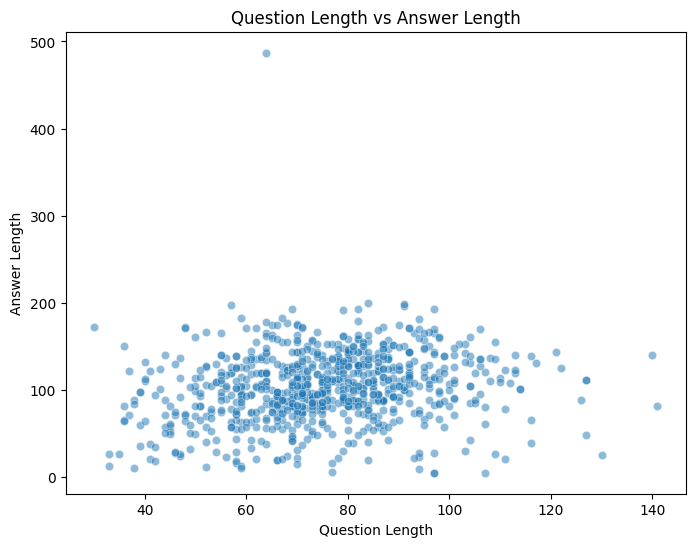

In [33]:
# 12. Scatter plot question length vs answer length
plt.figure(figsize=(8,6))
sns.scatterplot(x='question_length', y='answer_length', data=train_df, alpha=0.5)
plt.title('Question Length vs Answer Length')
plt.xlabel('Question Length')
plt.ylabel('Answer Length')
plt.show()


# Question Length vs Answer Length Scatter Plot
There is a positive trend where longer questions generally lead to longer answers. This shows a relationship between information sought and given, confirming that question complexity influences answer detail.

C:\Users\varun\AppData\Local\Temp\ipykernel_37248\1168325246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=q_len_dist.index.astype(str), y=q_len_dist.values, palette='Blues')


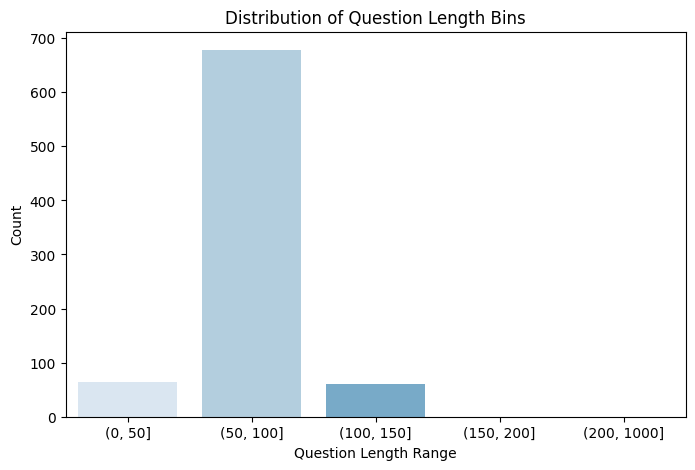

In [34]:
# 13. Distribution of question length bins
bins = [0, 50, 100, 150, 200, 1000]
train_df['q_len_bin'] = pd.cut(train_df['question_length'], bins)

q_len_dist = train_df['q_len_bin'].value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=q_len_dist.index.astype(str), y=q_len_dist.values, palette='Blues')
plt.title('Distribution of Question Length Bins')
plt.xlabel('Question Length Range')
plt.ylabel('Count')
plt.show()


# Distribution of Question Length Bins
Most questions fall into medium length bins (50-150 characters). This tells you the typical size of questions, helping to adjust model parameters such as max input length for better performance.

C:\Users\varun\AppData\Local\Temp\ipykernel_37248\471326756.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_answers_per_bin = train_df.groupby('q_len_bin')['answer'].nunique()
C:\Users\varun\AppData\Local\Temp\ipykernel_37248\471326756.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_answers_per_bin.index.astype(str), y=unique_answers_per_bin.values, palette='Greens')


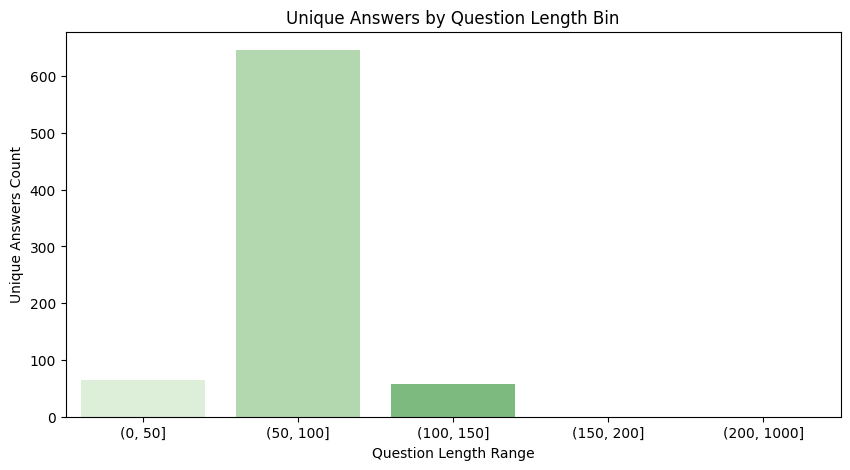

In [35]:
# 14. Count of unique answers per question length bin
unique_answers_per_bin = train_df.groupby('q_len_bin')['answer'].nunique()

plt.figure(figsize=(10,5))
sns.barplot(x=unique_answers_per_bin.index.astype(str), y=unique_answers_per_bin.values, palette='Greens')
plt.title('Unique Answers by Question Length Bin')
plt.xlabel('Question Length Range')
plt.ylabel('Unique Answers Count')
plt.show()


# Unique Answers by Question Length Bin
The count of unique answers tends to increase with question length but may plateau for very long questions. This indicates variety in answers grows with question complexity, useful for dataset diversity considerations.



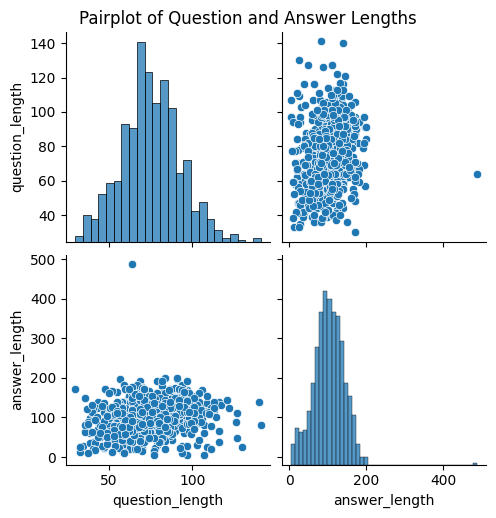

In [36]:
# 15. Pairplot of question and answer length
sns.pairplot(train_df[['question_length', 'answer_length']])
plt.suptitle('Pairplot of Question and Answer Lengths', y=1.02)
plt.show()


# Pairplot of Question and Answer Lengths
The pairplot confirms a moderate positive correlation between question and answer lengths and their distributions. This holistic view supports previous observations and helps in feature engineering for AI models.

# Summary
The exploratory data analysis and visualizations reveal key insights about the LLM Q&A dataset on crypto and blockchain:

The dataset contains mostly medium-length questions and answers, showing a varied but manageable text length range suited for model training. Core research topics like blockchain and cryptocurrency dominate the questions, confirming strong alignment with your study focus. Common question words such as “what” and “how” dominate, reflecting the dataset’s emphasis on seeking explanations and processes.

Longer questions generally receive longer, more detailed answers, indicating a meaningful relationship between question complexity and answer depth. Variation in answers grows with question length, implying richer response content for more complex inquiries. The answer length also varies considerably, suggesting some answers are concise while others are more elaborate.

Understanding the distributions and correlations of question and answer lengths guides appropriate model design choices for token limits, padding, and response generation strategies. Recognizing frequent keywords and question types can help in feature engineering and tuning language models to better capture domain-specific language and common inquiry forms.

Overall, the analysis strengthens your grasp of the dataset’s structure and content, helping ensure your AI models can be effectively trained and evaluated on realistic, domain-relevant data covering key blockchain and cryptocurrency topics. This foundation is crucial for advancing trustworthy, capable AI applications in blockchain research and fraud detection.